In [24]:
import pandas as pd
data = pd.read_csv(r'C:\Users\HP\Documents\DS project\DS_project\Fraudulent-prediction-project\data\cleaned_fraud_data.csv')


In [25]:
data= data.sort_values('timestamp').reset_index(drop=True)


In [26]:
categorical_cols = data.select_dtypes(include=['object','category']).columns
numerical_cols = data.select_dtypes(include=['int64','float64']).drop(columns=['is_fraud']).columns


split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
test_data = data[split_index:]

x_train = train_data.drop(columns=['is_fraud'])
y_train = train_data['is_fraud']
x_test = test_data.drop(columns=['is_fraud'])
y_test = test_data['is_fraud']


C:\Users\HP\AppData\Local\Temp\ipykernel_29420\4284115721.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object','category']).columns


standardization and encoding 


In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),categorical_cols),
        ('num', StandardScaler(), numerical_cols)
   ])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)


Train a Base model


              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1898
       Fraud       0.97      0.92      0.94       308

    accuracy                           0.98      2206
   macro avg       0.98      0.96      0.97      2206
weighted avg       0.98      0.98      0.98      2206



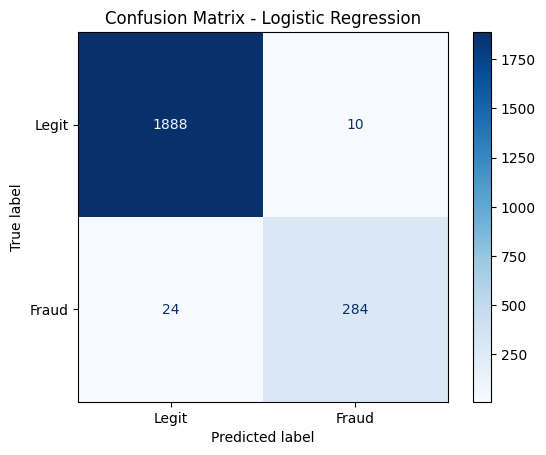

In [28]:
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(x_train_processed, y_train)

y_pred = lr_model.predict(x_test_processed)

print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
ConfusionMatrixDisplay.from_estimator(lr_model, x_test_processed, y_test, display_labels=['Legit', 'Fraud'], cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()


              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1898
       Fraud       0.95      0.92      0.93       308

    accuracy                           0.98      2206
   macro avg       0.97      0.96      0.96      2206
weighted avg       0.98      0.98      0.98      2206



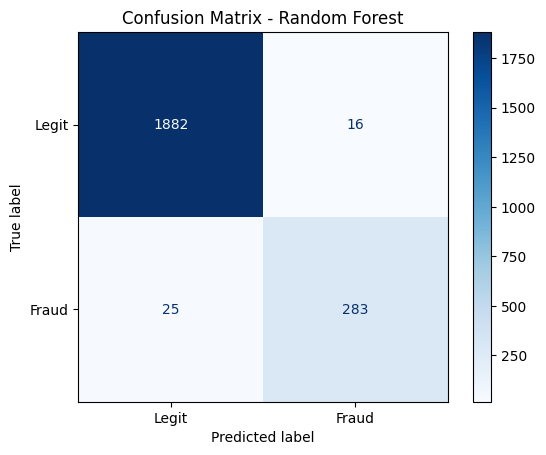

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, max_depth=10, n_jobs= -1
)
rf_model.fit(x_train_processed, y_train)
y_pred_rf = rf_model.predict(x_test_processed)
y_pred_rf_proba = rf_model.predict_proba(x_test_processed)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Legit', 'Fraud'], cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.show()


Hyperparameter Tuning



In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring='f1',
    verbose=1,
    random_state=42
)
rf_random_search.fit(x_train_processed, y_train)

for param, value in rf_random_search.best_params_.items():
    print(f"{param}: {value}")


Fitting 3 folds for each of 25 candidates, totalling 75 fits
n_estimators: 100
min_samples_split: 5
min_samples_leaf: 1
max_features: log2
max_depth: None
class_weight: balanced


              precision    recall  f1-score   support

       legit       0.99      1.00      0.99      1898
       fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2206
   macro avg       0.99      0.96      0.97      2206
weighted avg       0.99      0.99      0.99      2206



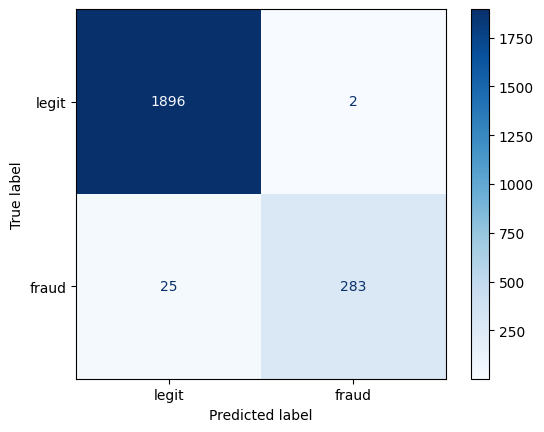

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
    n_estimators= 200,
    min_samples_split= 5,
    min_samples_leaf= 1,
    max_features= 'log2',
    max_depth= None,
    class_weight= 'balanced'
 ) 
rf_model.fit(x_train_processed, y_train)
y_pred_rf = rf_model.predict(x_test_processed)
y_pred_rf_proba = rf_model.predict_proba(x_test_processed)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['legit', 'fraud']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['legit', 'fraud'], cmap='Blues')


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer_rf = shap.TreeExplainer(rf_model)

# Compute SHAP values for first 100 samples
shap_values_rf = explainer_rf.shap_values(x_test_processed[:10].toarray())

# Get feature names
all_feature_names = preprocessor.get_feature_names_out()

# Select SHAP values for class 1 (adjust if needed)
shap_fraud = shap_values_rf[:, :, 1]  # safer for most classification cases

# Compute feature importance
feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": np.abs(shap_fraud).mean(axis=0)
}).sort_values("importance", ascending=False)

# Select top 15 features
top_15 = feature_importance.head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_15["feature"], top_15["importance"])
plt.xlabel("Mean |SHAP value|")
plt.title("Top 15 Features - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
print("Trees:", rf_model.n_estimators)


Trees: 200


In [ ]:
print("Features:", len(preprocessor.get_feature_names_out()))


Features: 26934


In [ ]:
print("Data shape:", x_test_processed.shape)


Data shape: (2206, 26934)


In [ ]:
for col in categorical_cols:
    print(col, data[col].nunique())


transaction_id 10836
customer_id 1314
timestamp 10835
home_country 4
source_currency 3
dest_currency 9
channel 4
ip_address 10836
ip_country 4
kyc_tier 4


In [37]:
import joblib

# Save the model and preprocessor
joblib.dump(rf_model, 'rf_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')


['preprocessor.joblib']